### Loading necessary dependencies

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import matplotlib.font_manager

### Loading and processing datasets

In [54]:
cogs = pd.read_csv('../Input_Data/eco_COGs.csv',
            sep = '\t')
cogs

,bnum,cogs,func
0,b0154,COG0001,H
1,b3958,COG0002,E
2,b0451,COG0004,P
3,b2407,COG0005,F
4,b3847,COG0006,E
...,...,...,...
3538,b1050,COG5645,S
3539,b3688,COG5645,S
3540,b2758,COG5934,V
3541,b2760,COG5942,V


In [55]:
cog_letter_func = {
    'J':'Translation, Ribosomal structure and biogenesis',
    'A':'RNA processing and modification',
    'K':'Transcription',
    'L':'Replication, recombination and repair',
    'B':'Chromatin structure and dynamics',
    'D':'Cell cycle control, cell division, chromosome partitioning',
    'Y':'Nuclear structure',
    'V':'Defense mechanisms',
    'T':'Signal transduction mechanisms',
    'M':'Cell wall, membrane and envelope biogenesis',
    'N':'Cell motility',
    'Z':'Cytoskeleton',
    'W':'Extracellular structures',
    'U':'Intracellular trafficking, secretion and vesicular transport',
    'O':'Postranscriptional modification, protein turnover, chaperones',
    'X':'Mobilome: prophages, transposons',
    'C':'Energy production and conversion',
    'G':'Carbohydrate transport and metabolism',
    'E':'Amino acid transport and metabolism',
    'F':'Nucleotide transport and metabolism',
    'H':'Coenzyme transport and metabolism',
    'I':'Lipid transport and metabolism',
    'P':'Inorganic ion transport and metabolism',
    'Q':'Secondary metabolites biosynthesis, transport and catabolism',
    'R':'General function prediction only',
    'S':'Function unknown'}
# cog_letter_func

In [56]:
cog_classes_dict = {'K':'Information',
                    'J':'Information',
                    'L':'Information',
                    'A':'Information',
                    'C':'Metabolism',
                    'F':'Metabolism',
                    'E':'Metabolism',
                    'P':'Metabolism',
                    'G':'Metabolism',
                    'I':'Metabolism',
                    'H':'Metabolism',
                    'Q':'Metabolism',
                    'O':'Signaling',
                    'U':'Signaling',
                    'M':'Signaling',
                    'D':'Signaling',
                    'T':'Signaling',
                    'V':'Signaling',
                    'N':'Signaling',
                    'R':'Poorly',
                    'S':'Poorly',
                    'W':'Other',
                    'X':'Other',
                    'B':'Other',
                    'Y':'Other',
                    'Z':'Other',
                    }
#cog_classes_dict

In [57]:
cog_classes_num_ord = {'K':1,
                    'J':1,
                    'L':1,
                    'A':1,
                    'C':2,
                    'F':2,
                    'E':2,
                    'P':2,
                    'G':2,
                    'I':2,
                    'H':2,
                    'Q':2,
                    'O':3,
                    'U':3,
                    'M':3,
                    'D':3,
                    'T':3,
                    'V':3,
                    'N':3,
                    'W':5,
                    'X':5,
                    'R':4,
                    'S':4,
                    'B':5,
                    'Y':5,
                    'Z':5,
                    'multiple':6,
                    'NA':7
                    }
#cog_classes_num_ord

In [58]:
cog_df = pd.DataFrame(columns = ['func_letter', 'function', 'COG_class'])
for key in cog_letter_func.keys():
    cog_df.loc[key] = [key, cog_letter_func[key], cog_classes_dict[key]]
#cog_df.to_csv('COG_letter_function_class_equivalence.csv', index = False)
cog_df.sort_values('COG_class')

,func_letter,function,COG_class
J,J,"Translation, Ribosomal structure and biogenesis",Information
A,A,RNA processing and modification,Information
K,K,Transcription,Information
L,L,"Replication, recombination and repair",Information
Q,Q,"Secondary metabolites biosynthesis, transport ...",Metabolism
P,P,Inorganic ion transport and metabolism,Metabolism
I,I,Lipid transport and metabolism,Metabolism
H,H,Coenzyme transport and metabolism,Metabolism
F,F,Nucleotide transport and metabolism,Metabolism
E,E,Amino acid transport and metabolism,Metabolism


In [59]:
COG_letter_functions = []
COG_classes_functions = []
for row, letters in enumerate(cogs.func.values):
    if len(letters) == 1:
        COG_letter_functions.append(cog_letter_func[letters])
        COG_classes_functions.append(cog_classes_dict[letters])
    else:
        string = ''
        class_string = ''
        delim = ','
        for character in letters:
            if character == ',':
                continue
            else:
                string = string + cog_letter_func[character] + delim
                class_string = class_string + cog_classes_dict[character] + delim
        string = string[:-1]
        class_string = class_string[:-1]
        COG_letter_functions.append(string)
        COG_classes_functions.append(class_string)
cogs['COG_function'] = COG_letter_functions
cogs['COG_class'] = COG_classes_functions
#cogs.to_csv('cogs_table_mod.csv', index = False)
cogs

,bnum,cogs,func,COG_function,COG_class
0,b0154,COG0001,H,Coenzyme transport and metabolism,Metabolism
1,b3958,COG0002,E,Amino acid transport and metabolism,Metabolism
2,b0451,COG0004,P,Inorganic ion transport and metabolism,Metabolism
3,b2407,COG0005,F,Nucleotide transport and metabolism,Metabolism
4,b3847,COG0006,E,Amino acid transport and metabolism,Metabolism
...,...,...,...,...,...
3538,b1050,COG5645,S,Function unknown,Poorly
3539,b3688,COG5645,S,Function unknown,Poorly
3540,b2758,COG5934,V,Defense mechanisms,Signaling
3541,b2760,COG5942,V,Defense mechanisms,Signaling


In [60]:
cogs_mod = cogs
cogs_mod = cogs_mod.drop('COG_class', axis = 1)
cogs_mod

,bnum,cogs,func,COG_function
0,b0154,COG0001,H,Coenzyme transport and metabolism
1,b3958,COG0002,E,Amino acid transport and metabolism
2,b0451,COG0004,P,Inorganic ion transport and metabolism
3,b2407,COG0005,F,Nucleotide transport and metabolism
4,b3847,COG0006,E,Amino acid transport and metabolism
...,...,...,...,...
3538,b1050,COG5645,S,Function unknown
3539,b3688,COG5645,S,Function unknown
3540,b2758,COG5934,V,Defense mechanisms
3541,b2760,COG5942,V,Defense mechanisms


In [61]:
ecocyc = pd.read_csv('../Input_Data/All-genes-of-E.-coli-K-12-substr-MG1655.txt', sep = '\t')
ecocyc.head()

,Gene Name,Accession-1,Left-End-Position,Right-End-Position,Product
0,rplS,b2606,2744183.0,2744530.0,50S ribosomal subunit protein L19
1,yibT,b4554,3776171.0,3776380.0,protein YibT
2,rrsH,b0201,223771.0,225312.0,16S ribosomal RNA
3,yabP,b0056,58474.0,59124.0,putative uncharacterized protein YabP
4,rrfE,b4010,4213040.0,4213159.0,5S ribosomal RNA


In [62]:
keio = pd.read_excel('../Input_Data/Map_KeioCollection.xlsx', sheet_name = 'Data2')
keio

/usr/local/miniconda3/envs/epistasis/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:312: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,Plate,Row,Col,JW_id,Strain,ECK number,Escherichia coli MG1655 B id,gene name,Comment
0,1,A,1,JW1950,1,ECK1963,b1967,hchA,NaN
1,1,B,1,JW3122,5,NaN,NaN,NaN,NaN
2,1,C,1,JW2201,1,ECK2205,b2213,ada,NaN
3,1,D,1,JW4077,3,ECK4109,b4116,adiY,NaN
4,1,E,1,JW0553,1,ECK0556,b0564,appY,NaN
...,...,...,...,...,...,...,...,...,...
8635,90,D,12,JW5874,2,ECK1645,b1649,ydhM,NaN
8636,90,E,12,JW5876,2,ECK2404,b2410,yfeH,NaN
8637,90,F,12,JW5877,2,ECK2405,b4546,ypeB,NaN
8638,90,G,12,JW5878,2,ECK2532,b2535,csiE,NaN


In [63]:
# Schmidt 2016 Suppl. Table S6
table = pd.read_excel('../Input_Data/41587_2016_BFnbt3418_MOESM18_ESM_Mod.xlsx',
                      sheet_name = 'Table S6',
                      skiprows = [0, 1])
# Protein copies per cell
protein_copies = table.iloc[:, [0,2,5,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,74,75,76,77]]
protein_copies = protein_copies.drop(labels = 2123, axis = 0) # Aquí se elimina la fila repetida
# Protein mass (fg) per cell
protein_mass = table.iloc[:, [0,2,5,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50, 74,75,76,77]]
protein_mass.columns = protein_copies.columns
protein_mass = protein_mass.drop(labels = 2123, axis = 0) # Aquí se elimina la fila repetida
conditions = table.columns[7:29]
protein_mass.head()

,Uniprot_Accession,Gene,Molecular_weight_Da,Glucose,LB,Glycerol_AA,Acetate,Fumarate,Glucosamine,Glycerol,...,pH6_glucose,Xylose,Mannose,Galactose,Succinate,Fructose,Bnumber,Annotated functional COG groups (letter),Annotated functional COG group (description),Annotated functional COG class
0,P0A8T7,rpoC,155045.0080,0.715349,1.844515,1.159331,0.561253,0.629318,0.853642,0.732347,...,0.859739,0.934963,0.875724,0.581381,0.711635,1.162894,b3988,K,Transcription,INFORMATION STORAGE AND PROCESSING
1,P0A8V2,rpoB,150520.2758,0.989135,2.221614,1.299346,0.665163,0.799515,0.999545,0.936990,...,1.007687,1.109002,1.035491,0.704953,0.963569,1.317061,b3987,K,Transcription,INFORMATION STORAGE AND PROCESSING
2,P36683,acnB,93420.9457,1.178283,2.575086,2.722244,3.543745,3.023680,2.133445,1.674174,...,0.721180,1.038963,2.562241,1.997324,3.032313,1.362394,b0118,C,Energy production and conversion,METABOLISM
3,P15254,purL,141295.8984,0.576304,0.192554,0.548796,0.337313,0.486028,0.459618,0.485143,...,0.400793,0.403734,0.413947,0.368480,0.448950,0.564445,b2557,F,Nucleotide transport and metabolism,METABOLISM
4,P09831,gltB,163176.3153,0.774653,0.163742,0.176652,0.369212,0.347026,0.535762,0.597161,...,0.737951,0.676351,0.563197,0.378829,0.420765,1.045406,b3212,E,Amino acid transport and metabolism,METABOLISM


In [64]:
fitness_table = pd.read_csv('../Input_Data/fit_organism_Keio.tsv', sep = '\t')
fitness_averages = pd.DataFrame()
fitness_averages['bnumber'] = fitness_table.sysName
fitness_averages.index = fitness_averages.bnumber
for column in range(5, 95, 2):
    fitness_averages[fitness_table.columns[column]] = [np.average([fitness_table.iloc[row, column],
                                                                 fitness_table.iloc[row, column+1]]) for row in
                                                                 range(len(fitness_table.index))]
fitness_averages['LB'] = [np.average([fitness_table.iloc[row, 112], fitness_table.iloc[row, 131]]) for
                          row in range(len(fitness_table.index))]

# We need selected fitness for the core proteome fractions
selected_fitness = fitness_averages.iloc[:, [0, 1, 12, 25, 19, 15, 4, 27, 5, 16, 2, 46]]
selected_fitness.columns = ['bnumber', 'Glucose', 'Acetate', 'Glucosamine', 'Glycerol', 'Pyruvate', 'Xylose', 'Mannose',
                            'Galactose', 'Succinate', 'Fructose', 'LB']
selected_fitness

,bnumber,Glucose,Acetate,Glucosamine,Glycerol,Pyruvate,Xylose,Mannose,Galactose,Succinate,Fructose,LB
bnumber,,,,,,,,,,,,
b4699,b4699,0.1550,0.4765,0.3080,-0.0835,0.2160,-0.2475,0.3465,0.4425,-0.0345,-0.2495,-0.2095
b4698,b4698,-0.0890,0.5080,-0.0410,-0.1060,-0.0775,-0.2600,-0.1845,-0.0365,0.6585,0.0165,0.2995
b4701,b4701,-0.1760,0.3565,0.4165,0.1215,0.0100,-0.0720,0.1405,-0.3220,-0.1635,0.1505,0.2535
b4704,b4704,-0.0870,-3.0840,-0.3755,-0.7370,-1.1035,-0.4450,0.0000,-0.7410,-0.9260,-0.3180,0.0510
b4702,b4702,-2.7585,-0.3845,-2.1700,-1.7570,-1.7255,-4.4145,-2.2295,-1.0885,-1.3270,-2.1070,-0.0320
...,...,...,...,...,...,...,...,...,...,...,...,...
b4687,b4687,0.3605,0.1550,0.2295,0.0905,0.0370,-0.0015,-0.0170,0.2445,-0.3075,0.1005,0.0770
b4684,b4684,-0.0385,-0.0390,-0.0050,-0.0890,-0.0545,-0.0270,0.0225,-0.1130,-0.0480,0.0795,-0.1125
b4685,b4685,-0.3170,-0.1350,-0.1085,-0.1975,-0.1845,-0.6005,-0.0810,-0.1480,-0.1575,-0.3085,-1.3530


## Constructing data frame for analysis

In [65]:
final_df = pd.DataFrame(columns = ['bnumber', 'gene_name', 'product', 'COG', 'COG_function',
                                   'COG_class'
                                  ])
for i, gene in enumerate(fitness_averages.index):
    
    # Gene product from ecocyc
    if gene in ecocyc['Accession-1'].values:
        product = ecocyc.loc[ecocyc['Accession-1'] == gene]['Product'].values[0]
    else:
        product = 'NA'
    
    # COG data
    # Letter
    if gene in cogs.bnum.values:
        gene_cog = cogs.loc[cogs.bnum == gene].func.values[0]
    else:
        gene_cog = 'NA'
    
    #Function
    if gene in cogs.bnum.values:
        gene_func = cogs.loc[cogs.bnum == gene].COG_function.values[0]
    else:
        gene_func = 'NA'
    
    # Class    
    if gene in cogs_mod.bnum.values:
        if len(cogs_mod.loc[cogs.bnum == gene].func.values[0]) == 1:
            COG_class = cog_classes_dict[cogs_mod.loc[cogs.bnum == gene].func.values[0]]
        else:
            COG_class = 'multiple'
    else:
        COG_class = 'NA'
    
    gene_row = [gene,
                fitness_table.loc[fitness_table.sysName == gene].geneName.values[0],
                product,
                gene_cog,
                gene_func,
                COG_class
               ]
    final_df.loc[gene] = gene_row

no_effect_column = []
essential_column = []
enhancing_column = []
important_column = []

for i, gene in enumerate(final_df.index):
    no_effect_to_sum = []
    essential_to_sum = []
    enhancing_to_sum = []
    important_to_sum = []
    for column in range(1, len(fitness_averages.columns)):
        if fitness_averages.iloc[i, column] >= -0.5 and fitness_averages.iloc[i, column] <= 0.5:
            no_effect_to_sum.append(1)
        elif fitness_averages.iloc[i, column] > 0.5:
            enhancing_to_sum.append(1)
        elif fitness_averages.iloc[i, column] <= -2:
            essential_to_sum.append(1)
        elif fitness_averages.iloc[i, column] > -2 and fitness_averages.iloc[i, column] < -0.5:
            important_to_sum.append(1)
    no_effect_column.append(np.asarray(no_effect_to_sum).sum())
    essential_column.append(np.asarray(essential_to_sum).sum())
    enhancing_column.append(np.asarray(enhancing_to_sum).sum())
    important_column.append(np.asarray(important_to_sum).sum())
final_df['sum_of_no-effect'] = no_effect_column
final_df['sum_of_essential'] = essential_column
final_df['sum_of_important'] = important_column
final_df['sum_of_enhancing'] = enhancing_column

fit_class_labels = ['no-effect', 'essential', 'important', 'enhancing'] # must be same order as in df columns
class_combination = []
for row, gene in enumerate(final_df.index):
    string = ''
    delimiter = '-'
    for n, fit_class in enumerate(final_df.iloc[row, 6:10].values):
        if fit_class > 0:
            string = string + fit_class_labels[n] + delimiter
    string = string[:-1]
    class_combination.append(string)
final_df['class_combination'] = class_combination

#cog_classes_num_ord
order = []
for gene in final_df.index:
    if len(final_df.loc[gene].COG) == 1:
        order.append(cog_classes_num_ord[final_df.loc[gene].COG])
    elif len(final_df.loc[gene].COG) == 2:
        order.append(cog_classes_num_ord['NA'])
    else:
        order.append(cog_classes_num_ord['multiple'])
final_df['order'] = order

r = 'indianred'
b = 'royalblue'
g = 'forestgreen'
m = 'darkorchid'
o = 'darkorange'
s = 'silver'
na = 'dimgrey'
colors_by_group = {'K':r, 'J':r, 'L':r, 'A':r,
                   
                   'C':b, 'F':b, 'E':b, 'P':b,
                   'G':b, 'I':b, 'H':b, 'Q':b,
                   
                   'O':g, 'U':g, 'M':g, 'D':g,
                   'T':g, 'V':g, 'N':g,
                   
                   'R':m, 'S':m,
                   
                   'W':o, 'X':o,
                   
                   'multiple':s,
                   
                   'NA':na,
          }
#colors
colores = []
for COG in final_df.COG:
    if len(COG) == 1:
        colores.append(colors_by_group[COG])
    elif len(COG) == 2:
        colores.append(colors_by_group['NA'])
    else:
        colores.append(colors_by_group['multiple'])
final_df['color_group'] = colores
# ---------------------------------------------------------------
fgs_means = []
fgs_stds = []
strains = []
plates = []
rows = []
columns = []

for n, gene in enumerate(final_df.index):
    if gene in protein_mass.Bnumber.values:
        fgs_means.append(np.nanmean(protein_mass.loc[protein_mass.Bnumber == gene].iloc[0,:].values[3:-4]))
        fgs_stds.append(np.nanstd(protein_mass.loc[protein_mass.Bnumber == gene].iloc[0,:].values[3:-4]))
    else:
        fgs_means.append('NA')
        fgs_stds.append('NA')
    
    if gene in keio['Escherichia coli MG1655 B id'].values:
        strains.append(keio.loc[keio['Escherichia coli MG1655 B id'] == gene]['Strain'].values)
        plates.append(keio.loc[keio['Escherichia coli MG1655 B id'] == gene]['Plate'].values)
        rows.append(keio.loc[keio['Escherichia coli MG1655 B id'] == gene]['Row'].values)
        columns.append(keio.loc[keio['Escherichia coli MG1655 B id'] == gene]['Col'].values)
    else:
        strains.append('NA')
        plates.append('NA')
        rows.append('NA')
        columns.append('NA')
        
final_df['fg_mean'] = fgs_means
final_df['fg_std'] = fgs_stds
final_df['strain'] = strains
final_df['plate'] = plates
final_df['row'] = rows
final_df['col'] = columns

final_df

,bnumber,gene_name,product,COG,COG_function,COG_class,sum_of_no-effect,sum_of_essential,sum_of_important,sum_of_enhancing,class_combination,order,color_group,fg_mean,fg_std,strain,plate,row,col
b4699,b4699,fnrS,small regulatory RNA FnrS,NA,NA,NA,42.0,0.0,2.0,2.0,no-effect-important-enhancing,7,dimgrey,NA,NA,NA,NA,NA,NA
b4698,b4698,mgrR,small regulatory RNA MgrR,NA,NA,NA,41.0,0.0,2.0,3.0,no-effect-important-enhancing,7,dimgrey,NA,NA,NA,NA,NA,NA
b4701,b4701,sokX,small RNA SokX,NA,NA,NA,46.0,0.0,0.0,0.0,no-effect,7,dimgrey,NA,NA,NA,NA,NA,NA
b4704,b4704,arrS,small regulatory RNA ArrS,NA,NA,NA,29.0,1.0,16.0,0.0,no-effect-essential-important,7,dimgrey,NA,NA,NA,NA,NA,NA
b4702,b4702,mgtL,leader peptide MgtL,NA,NA,NA,4.0,26.0,15.0,1.0,no-effect-essential-important-enhancing,7,dimgrey,NA,NA,NA,NA,NA,NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
b4687,b4687,shoB,toxic peptide ShoB,NA,NA,NA,46.0,0.0,0.0,0.0,no-effect,7,dimgrey,NA,NA,NA,NA,NA,NA
b4684,b4684,yqfG,uncharacterized protein YqfG,NA,NA,NA,46.0,0.0,0.0,0.0,no-effect,7,dimgrey,NA,NA,NA,NA,NA,NA
b4685,b4685,yrbN,uncharacterized protein YrbN,NA,NA,NA,32.0,0.0,14.0,0.0,no-effect-important,7,dimgrey,NA,NA,NA,NA,NA,NA
b4697,b4697,yrdF,NaN,NA,NA,NA,34.0,0.0,12.0,0.0,no-effect-important,7,dimgrey,NA,NA,NA,NA,NA,NA


### Plotting proteome mass fraction of each Fitness category in selected conditions

In [67]:
# Dictionary to contain data frames with fitness and proteomics data for each condition shared in both datasets
fg_and_F = {}

# Selecting shared conditions
for condition in list(set(protein_mass.columns).intersection(set(selected_fitness.columns)))[:]:
    df = pd.DataFrame()
    
    # Lists to contain values
    bnumbers = []
    fg = []
    Fitness = []
    fitness_classification = []
    
    # Selecting genes shared in both datasets
    for gene in set(protein_mass.Bnumber).intersection(set(selected_fitness.bnumber)):
        bnumbers.append(gene)
        fg.append(protein_mass.loc[protein_mass.Bnumber == gene][condition].values[0])
        Fitness.append(selected_fitness.loc[gene][condition])
        if selected_fitness.loc[gene][condition] <= -2:
            fitness_classification.append('essential')
        elif selected_fitness.loc[gene][condition] >= -0.5 and selected_fitness.loc[gene][condition] <= 0.5:
            fitness_classification.append('no_effect')
        elif selected_fitness.loc[gene][condition] > -2 and selected_fitness.loc[gene][condition] <-0.5:
            fitness_classification.append('important')
        elif selected_fitness.loc[gene][condition] > 0.5:
            fitness_classification.append('fitness-enhancing')
        else:
            fitness_classification.append('huh')
    
    # Creating the columns for each condition data frames
    df['bnumber'] = bnumbers
    df['fg'] = fg
    df['Fitness'] = Fitness
    df['classification'] = fitness_classification
    df['abs_fitness'] = [abs(f) for f in Fitness]
    
    # Adding the condition data frame to the containing dictionary
    fg_and_F[condition] = df

print('Conditions in the dictionary:', list(fg_and_F.keys()))
print('\nExample data frame:\n', df.head())

Conditions in the dictionary: ['Glycerol', 'Galactose', 'LB', 'Succinate', 'Xylose', 'Fructose', 'Glucosamine', 'Acetate', 'Pyruvate', 'Glucose', 'Mannose']

Example data frame:
   bnumber        fg  Fitness classification  abs_fitness
0   b2078  0.001356   0.0520      no_effect       0.0520
1   b4227  0.038949  -0.0695      no_effect       0.0695
2   b1583  0.007973   0.3495      no_effect       0.3495
3   b0838  0.017485   0.1225      no_effect       0.1225
4   b2181       NaN  -0.2220      no_effect       0.2220


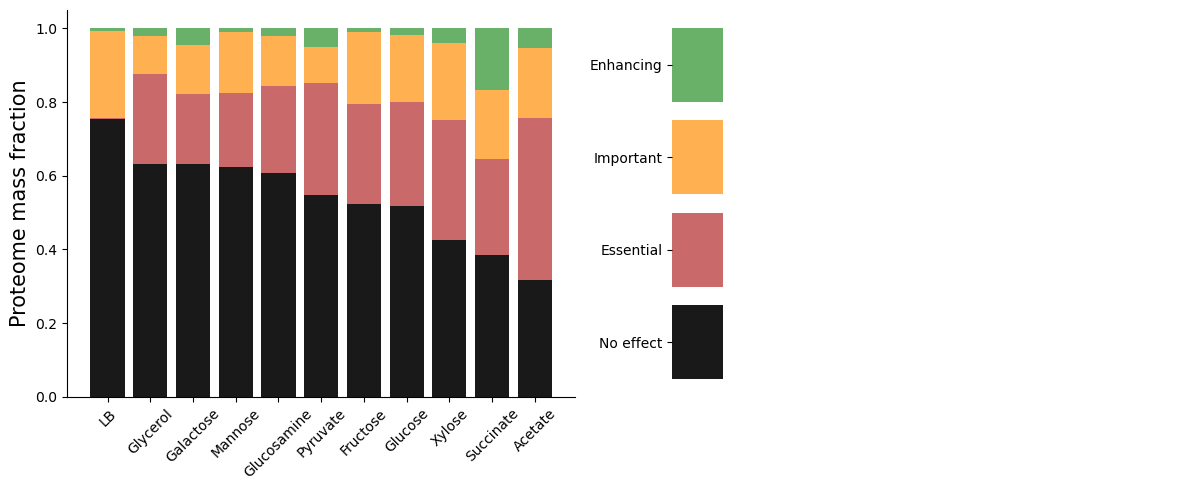

In [68]:
bar_width = 0.8
plt.figure(figsize = (12, 5))
ax = plt.subplot(1, 2, 1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for k, key in enumerate(['LB', 'Glycerol', 'Galactose', 'Mannose', 'Glucosamine', 'Pyruvate',
                         'Fructose', 'Glucose', 'Xylose', 'Succinate', 'Acetate']):
    plt.bar(key, 
          np.nansum([i for i in fg_and_F[key].loc[
                                fg_and_F[key].classification == 'no_effect'].fg.values if i != 'NA'])/
          np.nansum([i for i in fg_and_F[key].fg.values if i != 'NA']),
           color = 'black', width = bar_width, alpha = 0.9)
    plt.bar(key, 
          np.nansum([i for i in fg_and_F[key].loc[
                                fg_and_F[key].classification == 'essential'].fg.values if i != 'NA'])/
          np.nansum([i for i in fg_and_F[key].fg.values if i != 'NA']),
            bottom = 
          np.nansum([i for i in fg_and_F[key].loc[
                                fg_and_F[key].classification == 'no_effect'].fg.values if i != 'NA'])/
          np.nansum([i for i in fg_and_F[key].fg.values if i != 'NA']),
           color = 'firebrick', width = bar_width, alpha = 0.68)
    plt.bar(key, 
          np.nansum([i for i in fg_and_F[key].loc[
                                fg_and_F[key].classification == 'important'].fg.values if i != 'NA'])/
          np.nansum([i for i in fg_and_F[key].fg.values if i != 'NA']),
            bottom = 
          np.nansum([i for i in fg_and_F[key].loc[
                                (fg_and_F[key].classification == 'no_effect') |
                                (fg_and_F[key].classification == 'essential')
                                ].fg.values if i != 'NA'])/
          np.nansum([i for i in fg_and_F[key].fg.values if i != 'NA']),
           color = 'darkorange', width = bar_width, alpha = 0.68)
    plt.bar(key, 
          np.nansum([i for i in fg_and_F[key].loc[
                                fg_and_F[key].classification == 'fitness-enhancing'].fg.values if i != 'NA'])/
          np.nansum([i for i in fg_and_F[key].fg.values if i != 'NA']),
            bottom = 
          np.nansum([i for i in fg_and_F[key].loc[
                                (fg_and_F[key].classification == 'no_effect') |
                                (fg_and_F[key].classification == 'important') |
                                (fg_and_F[key].classification == 'essential')
                                ].fg.values if i != 'NA'])/
          np.nansum([i for i in fg_and_F[key].fg.values if i != 'NA']),
           color = 'forestgreen', width = bar_width, alpha = 0.68)
plt.xticks(rotation = 45)
plt.ylabel('Proteome mass fraction', fontsize = 15)
ax2= plt.subplot(1, 2, 2)
colores = ['k', 'firebrick', 'darkorange', 'forestgreen']
alphas = [0.9, 0.68, 0.68, 0.68]
for b, bar in enumerate(['No effect', 'Essential', 'Important', 'Enhancing']):
    plt.barh(bar, 0.1, color= colores[b], alpha = alphas[b])
plt.xlim(0, 1)
ax2.axes.get_xaxis().set_ticks([])
ax2.spines['top'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../Output/Figure_XX_Proteome_mass_fractions_by_Fitness_class.svg')

### Adding the fluxes to the fitness_classified dictionary
### ME simulations must be run first

In [69]:
# Importing fluxes
fluxes = pd.read_csv('../Input_Data/Updated_ME_fluxes.csv')
fluxes.index = fluxes.genes
fluxes

,genes,Glycerol,Galactose,Mannose,Glucosamine,Pyruvate,Fructose,Glucose,Xylose,Succinate,Acetate
genes,,,,,,,,,,,
b0002,b0002,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
b0003,b0003,2.253725e-06,2.070381e-06,2.100532e-06,2.034969e-06,2.038685e-06,2.251489e-06,2.259008e-06,1.508518e-06,2.080260e-06,1.119193e-06
b0004,b0004,4.563793e-05,4.192522e-05,4.253577e-05,4.120813e-05,4.128338e-05,4.559265e-05,4.574491e-05,3.054749e-05,4.212526e-05,2.266366e-05
b0007,b0007,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
b0008,b0008,0.000000e+00,3.441524e-05,3.485380e-05,3.363715e-05,3.440891e-05,3.708879e-05,2.565784e-05,8.756334e-05,9.032648e-06,3.872961e-06
...,...,...,...,...,...,...,...,...,...,...,...
b4388,b4388,2.973658e-07,2.817729e-07,2.861577e-07,2.740346e-07,2.563854e-07,3.066434e-07,3.088391e-07,2.064376e-07,2.597503e-07,1.431506e-07
b4390,b4390,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
b4392,b4392,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


### Plotting proteome mass fraction of no-effect genes with translation flux (from ME model)

In [70]:
fitness_classified = {}
for column in selected_fitness.columns[1:-1]:
    fitness_classified[column] = pd.DataFrame()
    fitness_classified[column]['bnumber'] = list(set(selected_fitness.index))# & set(model_df.index))
    fitness_classified[column].index = fitness_classified[column]['bnumber']#selected_fitness['bnumber']
    fitness_classified[column]['Fitness'] = selected_fitness[column]
    fitness_classification = []
    fg = []
    flux = []
    for gene in fitness_classified[column].index:
        if fitness_classified[column].loc[gene].Fitness <= -2:
            fitness_classification.append('essential')
        elif fitness_classified[column].loc[gene].Fitness >= -0.5 and fitness_classified[column].loc[gene].Fitness <= 0.5:
            fitness_classification.append('no_effect')
        elif fitness_classified[column].loc[gene].Fitness > -2 and fitness_classified[column].loc[gene].Fitness <-0.5:
            fitness_classification.append('important')
        elif fitness_classified[column].loc[gene].Fitness > 0.5:
            fitness_classification.append('fitness-enhancing')
        else:
            fitness_classification.append('huh')
        if gene in protein_mass.Bnumber.values:
            fg.append(protein_mass.loc[protein_mass.Bnumber == gene][column].values[0])
        else:
            fg.append('NA')
        if gene in fluxes.index:
            flux.append(fluxes.loc[gene][column])
        else:
            flux.append('NA')
    fitness_classified[column]['classification'] = fitness_classification
    fitness_classified[column]['fg'] = fg
    fitness_classified[column]['flux'] = flux
print(fitness_classified.keys())
fitness_classified['Glucose']

dict_keys(['Glucose', 'Acetate', 'Glucosamine', 'Glycerol', 'Pyruvate', 'Xylose', 'Mannose', 'Galactose', 'Succinate', 'Fructose'])


,bnumber,Fitness,classification,fg,flux
bnumber,,,,,
b0303,b0303,-0.3740,no_effect,NA,NA
b1218,b1218,-0.2540,no_effect,NA,NA
b2078,b2078,0.1395,no_effect,0.000791,NA
b0341,b0341,0.1465,no_effect,NA,0.0
b0838,b0838,-0.0610,no_effect,0.024636,NA
...,...,...,...,...,...
b2483,b2483,0.1160,no_effect,NA,0.0
b0378,b0378,0.0415,no_effect,0.000045,NA
b0586,b0586,-0.0805,no_effect,0.010065,0.0


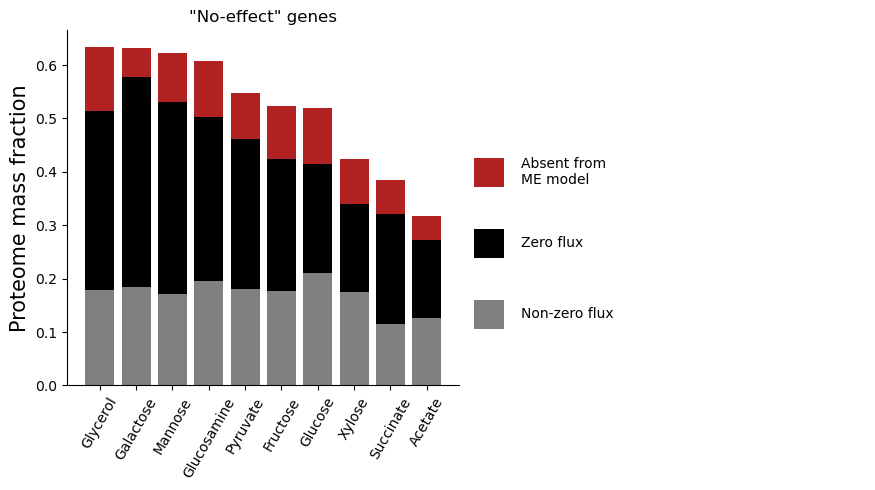

In [71]:
plt.figure(figsize = (12, 5))
ax = plt.subplot(1, 2, 1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for k, key in enumerate(['Glycerol', 'Galactose', 'Mannose', 'Glucosamine', 'Pyruvate', 'Fructose',
                         'Glucose', 'Xylose', 'Succinate', 'Acetate']):#enumerate(list(fitness_classified.keys())):
    all_gene_fg =  fitness_classified[key].loc[fitness_classified[key].fg != 'NA'].fg.sum()
    all_no_effect_fg = fitness_classified[key].loc[
                (fitness_classified[key].classification == 'no_effect') &
                (fitness_classified[key].fg != 'NA')].fg.sum()
    no_effect_no_ME = fitness_classified[key].loc[
                (fitness_classified[key].classification == 'no_effect') &
                (fitness_classified[key].fg != 'NA')&
                (fitness_classified[key].flux == 'NA')].fg.sum()
    no_effect_zero_flux = fitness_classified[key].loc[
                (fitness_classified[key].classification == 'no_effect') &
                (fitness_classified[key].fg != 'NA')&
                (fitness_classified[key].flux == 0)].fg.sum()
    no_effect_Non_zero_flux = fitness_classified[key].loc[
                (fitness_classified[key].classification == 'no_effect') &
                (fitness_classified[key].fg != 'NA')&
                (fitness_classified[key].flux != 'NA')&
                (fitness_classified[key].flux != 0)].fg.sum()
    
    plt.title('"No-effect" genes')

    plt.bar([key], # todos menos los no-effect más no-effno-ME
            (no_effect_no_ME) / all_gene_fg,
            #bottom = (all_gene_fg - all_no_effect_fg) / all_gene_fg,
            color = 'grey')
    plt.bar([key], # no effect and zero flux
            (no_effect_zero_flux) / all_gene_fg,
            bottom = (no_effect_no_ME) / all_gene_fg,
            color = 'k')
    plt.bar([key], # no effect and zero flux
            (no_effect_Non_zero_flux) / all_gene_fg,
            bottom = (no_effect_no_ME + no_effect_zero_flux) / all_gene_fg,
            color = 'firebrick')
    plt.xticks(rotation = 60)
    plt.ylabel('Proteome mass fraction', fontsize = 15)

ax2 = plt.subplot(1, 2, 2)
ax2.spines['top'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_visible(False)

colores = ['grey', 'k', 'firebrick']
bars = ['Non-zero flux', 'Zero flux', 'Absent from\nME model']

bar_values = [0.05, 0.05, 0.05]

y_positions = [0.1, 0.2, 0.3]

bar_height = 0.2

for b, (bar, y) in enumerate(zip(bars, y_positions)):
    ax2.barh(y, bar_values[b]*1.5, color=colores[b], height=0.04)
    # Add labels on the right side of the bars
    ax2.text(bar_values[b] + 0.07, y, bars[b], va='center', color='black', fontsize=10)
    
# Hide x and y ticks
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_yticklabels([])

plt.tight_layout()
plt.xlim(0, 1)
plt.ylim(0, 0.5)
   
plt.savefig('../Output/Figure_XX_Prot_Mass_Frac_No_Effect_w_ME_flux.svg')

In [72]:
core_classified = {}
for column in selected_fitness.columns[1:]:
    core_classified[column] = pd.DataFrame()
    core_classified[column]['bnumber'] = selected_fitness.bnumber
    core_classified[column].index = core_classified[column]['bnumber']
    core_classified[column]['Fitness'] = selected_fitness[column]
    core_classification = []
    fgs = []
    for gene in selected_fitness[column].index:
        if core_classified[column].loc[gene].Fitness <= -2:
            core_classification.append('essential')
        elif core_classified[column].loc[gene].Fitness >= -0.5 and core_classified[column].loc[gene].Fitness <= 0.5:
            core_classification.append('no_effect')
        elif core_classified[column].loc[gene].Fitness > -2 and core_classified[column].loc[gene].Fitness <-0.5:
            core_classification.append('important')
        elif core_classified[column].loc[gene].Fitness > 0.5:
            core_classification.append('fitness-enhancing')
        else:
            core_classification.append('huh')
        if gene in protein_mass.Bnumber.values:
            fgs.append(protein_mass.loc[protein_mass.Bnumber == gene][column].values[0])
        else:
            fgs.append(0)

    core_classified[column]['classification'] = core_classification
    core_classified[column]['fg'] = fgs

core_classified['Glucose']

,bnumber,Fitness,classification,fg
bnumber,,,,
b4699,b4699,0.1550,no_effect,0.0
b4698,b4698,-0.0890,no_effect,0.0
b4701,b4701,-0.1760,no_effect,0.0
b4704,b4704,-0.0870,no_effect,0.0
b4702,b4702,-2.7585,essential,0.0
...,...,...,...,...
b4687,b4687,0.3605,no_effect,0.0
b4684,b4684,-0.0385,no_effect,0.0
b4685,b4685,-0.3170,no_effect,0.0


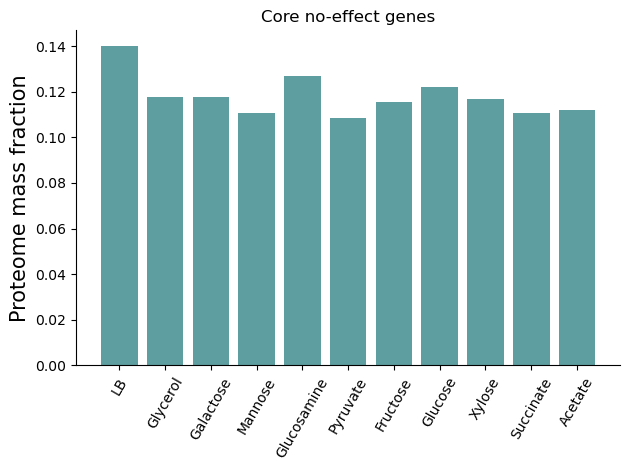

In [73]:
#plt.subplot(1, 2, 1)
ax = plt.subplot(1, 1, 1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for k, key in enumerate(['LB', 'Glycerol', 'Galactose', 'Mannose', 'Glucosamine', 'Pyruvate', 'Fructose',
                         'Glucose', 'Xylose', 'Succinate', 'Acetate']):
    #plt.subplot(4, 4, k-1)
    plt.bar(key, core_classified[key].loc[final_df.loc[final_df['sum_of_no-effect'] == 46].index].fg.sum()/
            core_classified[key].fg.sum(),
           color = 'cadetblue')
# print(core_classified[key].loc[core_classified[key].classification == 'no_effect'].fg.sum())
# print(core_classified[key].fg.sum())
plt.xticks(rotation = 60)
plt.ylabel('Proteome mass fraction', fontsize = 15)
plt.title('Core no-effect genes')

plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
plt.savefig('../Output/Figure_XX_Core_No_Effect_Prot_Frac.svg')

### Plotting pie chart with COGs

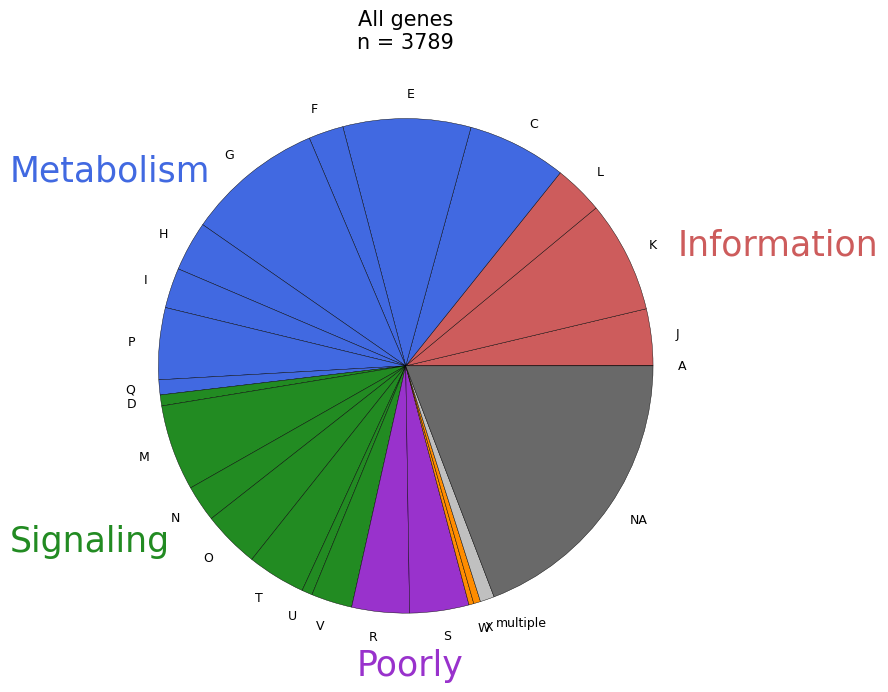

In [74]:
# Pie chart with COG categories
pie_values = []
pie_labels = []
pie_colors = []
multiple_count = 0
for letter in final_df.sort_values(['order', 'COG']).COG.unique():
    if len(letter) == 1:
        pie_labels.append(letter)
        pie_values.append(len(final_df.loc[final_df.COG == letter].index))
        pie_colors.append(final_df.loc[final_df.COG == letter].color_group.values[0])
    elif len(letter) > 2:
        multiple_count += 1
pie_colors.append('silver')
pie_labels.append('multiple')
pie_values.append(multiple_count)

for letter in final_df.sort_values(['order', 'COG']).COG.unique():
    if len(letter) == 2:
        pie_labels.append('NA')
        pie_values.append(len(final_df.loc[final_df.COG == letter].index))
        pie_colors.append(final_df.loc[final_df.COG == letter].color_group.values[0])

plt.figure(figsize = (9, 9))
plt.title('All genes\nn = ' +
              str(len(final_df.index)),
              fontsize = 15)
plt.pie(pie_values,
            labels = pie_labels,
            colors = pie_colors,
            textprops={'fontsize': 9},
            wedgeprops = {'linewidth':0.3,
                          'edgecolor':'k'
                          })
plt.text(1.1, 0.45, 'Information', color = 'indianred', fontsize = 25)
plt.text(-1.6, 0.75, 'Metabolism', color = 'royalblue', fontsize = 25)
plt.text(-1.6, -0.75, 'Signaling', color = 'forestgreen', fontsize = 25)
plt.text(-0.2, -1.25, 'Poorly', color = 'darkorchid', fontsize = 25)

plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
plt.savefig('../Output/Fitness_Cogs_Pie.svg')

In [75]:
# There are  4691 unique genes in the ecocyc dataset
# There are  3789 unique genes in the fitness datasety
# There are  1568 unique genes in the ME_model dataset
# There are  3897 unique genes in the Keio dataset
# ------------------------------------------

# There are 3782 shared genes in the ecocyc and Fitness datasets
# There are 1568 shared genes in the ecocyc and ME model datasets
# There are 1261 shared genes in the Fitness and ME model datasets
# There are 3822 shared genes in the Keio and ecocyc datasets
# There are 3573 shared genes in the Keio and Fitness datasets
# There are 1260 shared genes in the Keio and ME model datasets
# ------------------------------------------

# There are 1237 shared genes in the four datasets

In [76]:
final_df.loc[final_df['sum_of_no-effect'] == 46]

,bnumber,gene_name,product,COG,COG_function,COG_class,sum_of_no-effect,sum_of_essential,sum_of_important,sum_of_enhancing,class_combination,order,color_group,fg_mean,fg_std,strain,plate,row,col
b4701,b4701,sokX,small RNA SokX,NA,NA,NA,46.0,0.0,0.0,0.0,no-effect,7,dimgrey,NA,NA,NA,NA,NA,NA
b0005,b0005,yaaX,DUF2502 domain-containing protein YaaX,NA,NA,NA,46.0,0.0,0.0,0.0,no-effect,7,dimgrey,NA,NA,"[1, 2]","[17, 18]","[E, E]","[6, 6]"
b0006,b0006,yaaA,DNA binding and peroxide stress response prote...,L,"Replication, recombination and repair",Information,46.0,0.0,0.0,0.0,no-effect,1,indianred,0.026931,0.01228,"[1, 3]","[27, 28]","[C, C]","[10, 10]"
b0010,b0010,yaaH,acetate/succinate:H<sup>+</sup> symporter,C,Energy production and conversion,Metabolism,46.0,0.0,0.0,0.0,no-effect,2,royalblue,NA,NA,"[2, 3]","[19, 20]","[B, B]","[2, 2]"
b0011,b0011,yaaW,putative enzyme-specific chaperone YaaW,S,Function unknown,Poorly,46.0,0.0,0.0,0.0,no-effect,4,darkorchid,NA,NA,"[1, 2]","[27, 28]","[D, D]","[10, 10]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
b4693,b4693,aaaE,phage terminase,NA,NA,NA,46.0,0.0,0.0,0.0,no-effect,7,dimgrey,NA,NA,NA,NA,NA,NA
b4696,b4696,yneO,AIDA-I family autotransporter YneO,NA,NA,NA,46.0,0.0,0.0,0.0,no-effect,7,dimgrey,NA,NA,NA,NA,NA,NA
b4675,b4675,yoaJ,uncharacterized protein YoaJ,NA,NA,NA,46.0,0.0,0.0,0.0,no-effect,7,dimgrey,NA,NA,NA,NA,NA,NA
b4687,b4687,shoB,toxic peptide ShoB,NA,NA,NA,46.0,0.0,0.0,0.0,no-effect,7,dimgrey,NA,NA,NA,NA,NA,NA


In [77]:
len(set(protein_mass.Bnumber).intersection(set(selected_fitness.bnumber)))

1951

In [78]:
for k, key in enumerate(fg_and_F.keys()):
    print(key,
          len(fg_and_F[key].loc[fg_and_F[key].classification == 'no_effect'].index),
          round(len(fg_and_F[key].loc[fg_and_F[key].classification == 'no_effect'].index)/len(fg_and_F[key].index), 4)
         )


Glycerol 1658 0.8498
Galactose 1650 0.8457
LB 1796 0.9206
Succinate 1361 0.6976
Xylose 1541 0.7899
Fructose 1681 0.8616
Glucosamine 1669 0.8555
Acetate 1364 0.6991
Pyruvate 1621 0.8309
Glucose 1671 0.8565
Mannose 1661 0.8514


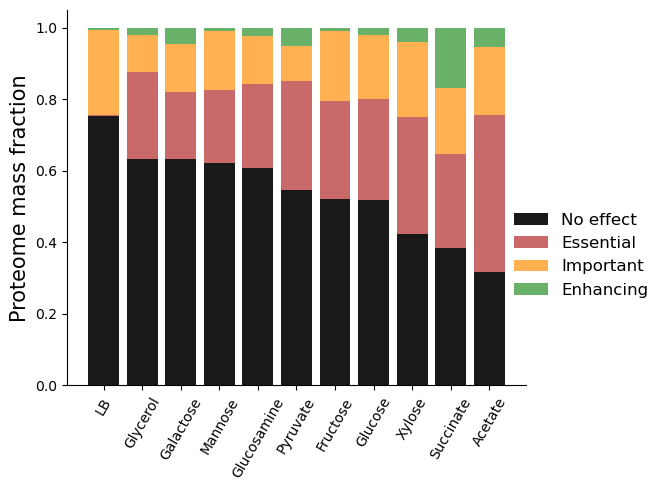

In [82]:
bar_width = 0.8
plt.figure(figsize=(7, 5))
ax = plt.subplot(1, 1, 1)  # Single subplot

# Customize the main plot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Loop through each key to plot bars
for k, key in enumerate(['LB', 'Glycerol', 'Galactose', 'Mannose', 'Glucosamine', 'Pyruvate',
                         'Fructose', 'Glucose', 'Xylose', 'Succinate', 'Acetate']):
    plt.bar(key, 
          np.nansum([i for i in fg_and_F[key].loc[
                                fg_and_F[key].classification == 'no_effect'].fg.values if i != 'NA']) /
          np.nansum([i for i in fg_and_F[key].fg.values if i != 'NA']),
           color='black', width=bar_width, alpha=0.9, label='No effect' if k == 0 else "")
    plt.bar(key, 
          np.nansum([i for i in fg_and_F[key].loc[
                                fg_and_F[key].classification == 'essential'].fg.values if i != 'NA']) /
          np.nansum([i for i in fg_and_F[key].fg.values if i != 'NA']),
            bottom= 
          np.nansum([i for i in fg_and_F[key].loc[
                                fg_and_F[key].classification == 'no_effect'].fg.values if i != 'NA']) /
          np.nansum([i for i in fg_and_F[key].fg.values if i != 'NA']),
           color='firebrick', width=bar_width, alpha=0.68, label='Essential' if k == 0 else "")
    plt.bar(key, 
          np.nansum([i for i in fg_and_F[key].loc[
                                fg_and_F[key].classification == 'important'].fg.values if i != 'NA']) /
          np.nansum([i for i in fg_and_F[key].fg.values if i != 'NA']),
            bottom= 
          np.nansum([i for i in fg_and_F[key].loc[
                                (fg_and_F[key].classification == 'no_effect') |
                                (fg_and_F[key].classification == 'essential')
                                ].fg.values if i != 'NA']) /
          np.nansum([i for i in fg_and_F[key].fg.values if i != 'NA']),
           color='darkorange', width=bar_width, alpha=0.68, label='Important' if k == 0 else "")
    plt.bar(key, 
          np.nansum([i for i in fg_and_F[key].loc[
                                fg_and_F[key].classification == 'fitness-enhancing'].fg.values if i != 'NA']) /
          np.nansum([i for i in fg_and_F[key].fg.values if i != 'NA']),
            bottom= 
          np.nansum([i for i in fg_and_F[key].loc[
                                (fg_and_F[key].classification == 'no_effect') |
                                (fg_and_F[key].classification == 'important') |
                                (fg_and_F[key].classification == 'essential')
                                ].fg.values if i != 'NA']) /
          np.nansum([i for i in fg_and_F[key].fg.values if i != 'NA']),
           color='forestgreen', width=bar_width, alpha=0.68, label='Enhancing' if k == 0 else "")
plt.xticks(rotation=60)
plt.ylabel('Proteome mass fraction', fontsize=15)

# Add the legend
ax.legend(loc='upper right',
          fontsize = 12,
          bbox_to_anchor=(1.3, 0.5), frameon=False)

plt.tight_layout()
plt.show()

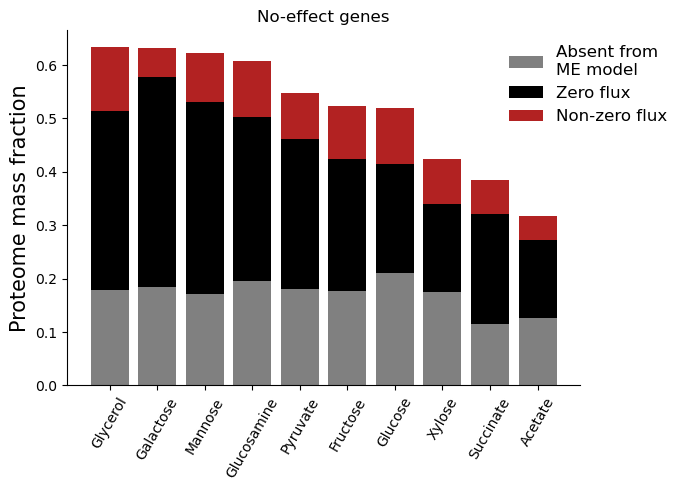

In [83]:
# Create the main figure and axes
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

# Customize the main plot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for k, key in enumerate(['Glycerol', 'Galactose', 'Mannose', 'Glucosamine', 'Pyruvate', 'Fructose',
                         'Glucose', 'Xylose', 'Succinate', 'Acetate']):
    all_gene_fg =  fitness_classified[key].loc[fitness_classified[key].fg != 'NA'].fg.sum()
    all_no_effect_fg = fitness_classified[key].loc[
                (fitness_classified[key].classification == 'no_effect') &
                (fitness_classified[key].fg != 'NA')].fg.sum()
    no_effect_no_ME = fitness_classified[key].loc[
                (fitness_classified[key].classification == 'no_effect') &
                (fitness_classified[key].fg != 'NA')&
                (fitness_classified[key].flux == 'NA')].fg.sum()
    no_effect_zero_flux = fitness_classified[key].loc[
                (fitness_classified[key].classification == 'no_effect') &
                (fitness_classified[key].fg != 'NA')&
                (fitness_classified[key].flux == 0)].fg.sum()
    no_effect_Non_zero_flux = fitness_classified[key].loc[
                (fitness_classified[key].classification == 'no_effect') &
                (fitness_classified[key].fg != 'NA')&
                (fitness_classified[key].flux != 'NA')&
                (fitness_classified[key].flux != 0)].fg.sum()

    plt.title('No-effect genes')

    ax.bar([key], 
           (no_effect_no_ME) / all_gene_fg,
           color='grey', label='Absent from\nME model' if k == 0 else "")
    ax.bar([key], 
           (no_effect_zero_flux) / all_gene_fg,
           bottom=(no_effect_no_ME) / all_gene_fg,
           color='k', label='Zero flux' if k == 0 else "")
    ax.bar([key], 
           (no_effect_Non_zero_flux) / all_gene_fg,
           bottom=(no_effect_no_ME + no_effect_zero_flux) / all_gene_fg,
           color='firebrick', label='Non-zero flux' if k == 0 else "")

ax.set_xticks(range(len(['Glycerol', 'Galactose', 'Mannose', 'Glucosamine', 'Pyruvate', 'Fructose',
                         'Glucose', 'Xylose', 'Succinate', 'Acetate'])))
ax.set_xticklabels(['Glycerol', 'Galactose', 'Mannose', 'Glucosamine', 'Pyruvate', 'Fructose',
                    'Glucose', 'Xylose', 'Succinate', 'Acetate'], rotation=60)
ax.set_ylabel('Proteome mass fraction', fontsize=15)

# Add the legend
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1),  frameon=False, fontsize = 12)

plt.tight_layout()
plt.show()

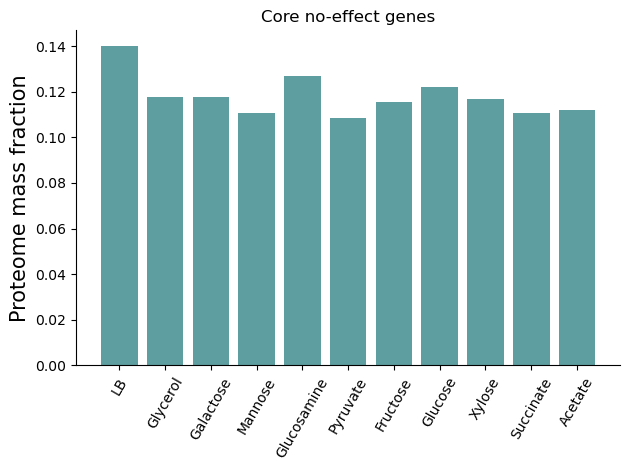

In [84]:
#plt.subplot(1, 2, 1)
ax = plt.subplot(1, 1, 1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for k, key in enumerate(['LB', 'Glycerol', 'Galactose', 'Mannose', 'Glucosamine', 'Pyruvate', 'Fructose',
                         'Glucose', 'Xylose', 'Succinate', 'Acetate']):
    #plt.subplot(4, 4, k-1)
    plt.bar(key, core_classified[key].loc[final_df.loc[final_df['sum_of_no-effect'] == 46].index].fg.sum()/
            core_classified[key].fg.sum(),
           color = 'cadetblue')
# print(core_classified[key].loc[core_classified[key].classification == 'no_effect'].fg.sum())
# print(core_classified[key].fg.sum())
plt.xticks(rotation = 60)
plt.ylabel('Proteome mass fraction', fontsize = 15)
plt.title('Core no-effect genes')

plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'

/tmp/ipykernel_37989/4150665059.py:50: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(['LB', 'Glycerol', 'Galactose', 'Mannose', 'Glucosamine', 'Pyruvate',


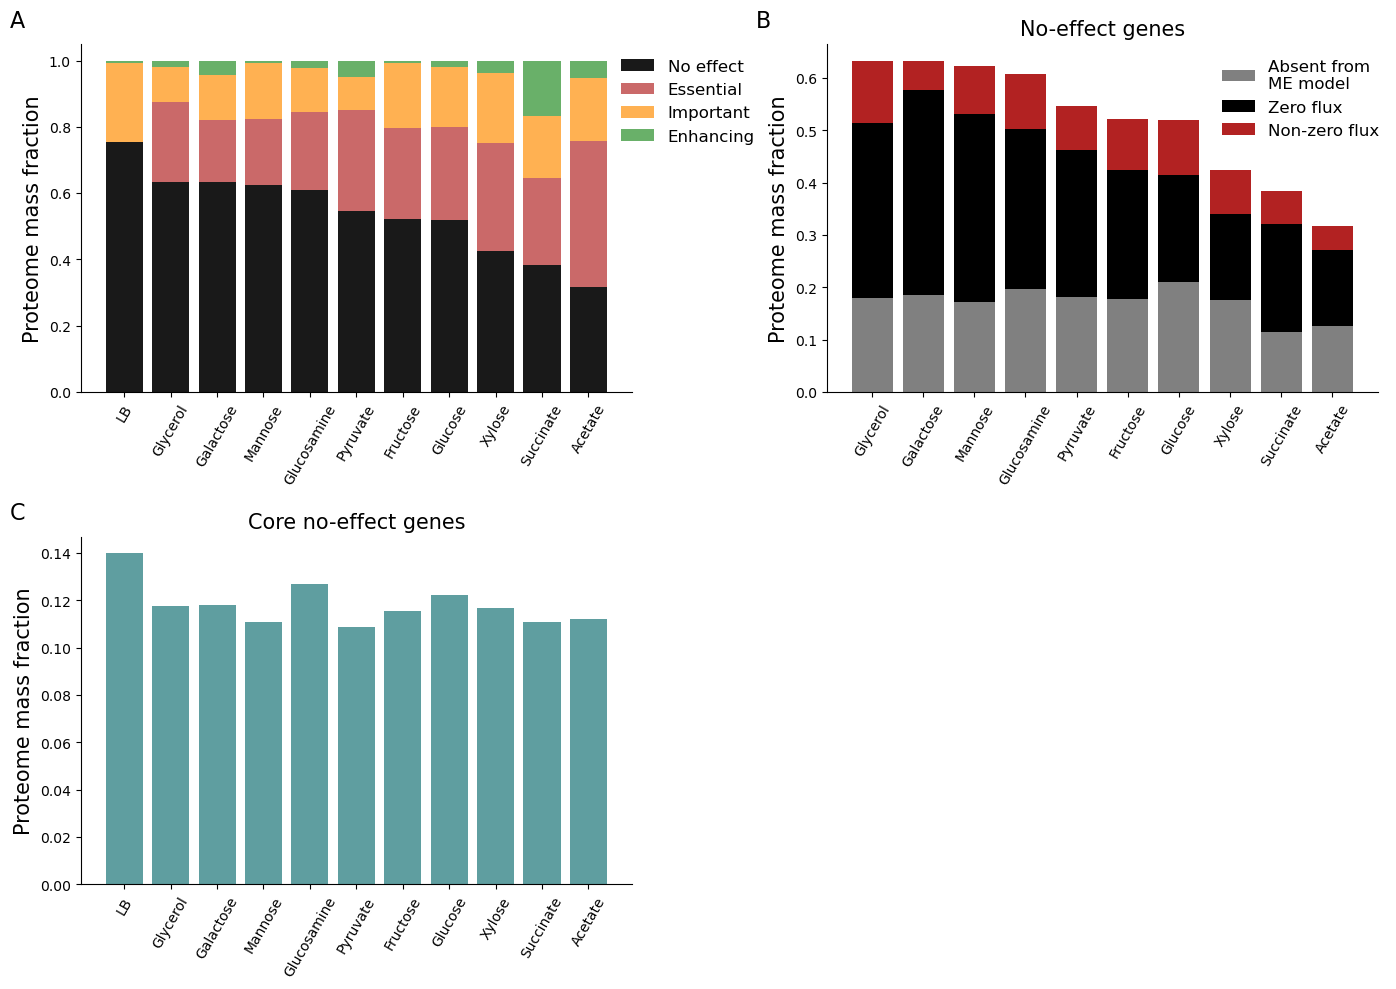

In [85]:
# Create a figure with a 2x2 grid of subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# First Plot
bar_width = 0.8
ax1 = axs[0, 0]
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

for k, key in enumerate(['LB', 'Glycerol', 'Galactose', 'Mannose', 'Glucosamine', 'Pyruvate',
                         'Fructose', 'Glucose', 'Xylose', 'Succinate', 'Acetate']):
    ax1.bar(key, 
          np.nansum([i for i in fg_and_F[key].loc[
                                fg_and_F[key].classification == 'no_effect'].fg.values if i != 'NA']) /
          np.nansum([i for i in fg_and_F[key].fg.values if i != 'NA']),
           color='black', width=bar_width, alpha=0.9, label='No effect' if k == 0 else "")
    ax1.bar(key, 
          np.nansum([i for i in fg_and_F[key].loc[
                                fg_and_F[key].classification == 'essential'].fg.values if i != 'NA']) /
          np.nansum([i for i in fg_and_F[key].fg.values if i != 'NA']),
            bottom= 
          np.nansum([i for i in fg_and_F[key].loc[
                                fg_and_F[key].classification == 'no_effect'].fg.values if i != 'NA']) /
          np.nansum([i for i in fg_and_F[key].fg.values if i != 'NA']),
           color='firebrick', width=bar_width, alpha=0.68, label='Essential' if k == 0 else "")
    ax1.bar(key, 
          np.nansum([i for i in fg_and_F[key].loc[
                                fg_and_F[key].classification == 'important'].fg.values if i != 'NA']) /
          np.nansum([i for i in fg_and_F[key].fg.values if i != 'NA']),
            bottom= 
          np.nansum([i for i in fg_and_F[key].loc[
                                (fg_and_F[key].classification == 'no_effect') |
                                (fg_and_F[key].classification == 'essential')
                                ].fg.values if i != 'NA']) /
          np.nansum([i for i in fg_and_F[key].fg.values if i != 'NA']),
           color='darkorange', width=bar_width, alpha=0.68, label='Important' if k == 0 else "")
    ax1.bar(key, 
          np.nansum([i for i in fg_and_F[key].loc[
                                fg_and_F[key].classification == 'fitness-enhancing'].fg.values if i != 'NA']) /
          np.nansum([i for i in fg_and_F[key].fg.values if i != 'NA']),
            bottom= 
          np.nansum([i for i in fg_and_F[key].loc[
                                (fg_and_F[key].classification == 'no_effect') |
                                (fg_and_F[key].classification == 'important') |
                                (fg_and_F[key].classification == 'essential')
                                ].fg.values if i != 'NA']) /
          np.nansum([i for i in fg_and_F[key].fg.values if i != 'NA']),
           color='forestgreen', width=bar_width, alpha=0.68, label='Enhancing' if k == 0 else "")

ax1.set_xticklabels(['LB', 'Glycerol', 'Galactose', 'Mannose', 'Glucosamine', 'Pyruvate',
                     'Fructose', 'Glucose', 'Xylose', 'Succinate', 'Acetate'], rotation=60)
ax1.set_ylabel('Proteome mass fraction', fontsize=15)
ax1.legend(loc='upper right', fontsize=12, bbox_to_anchor=(1.25, 1), frameon=False)
ax1.text(-0.1, 1.1, 'A', transform=ax1.transAxes, fontsize=16,
         #fontweight='bold',
         va='top', ha='right')

# Second Plot
ax2 = axs[0, 1]
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

for k, key in enumerate(['Glycerol', 'Galactose', 'Mannose', 'Glucosamine', 'Pyruvate', 'Fructose',
                         'Glucose', 'Xylose', 'Succinate', 'Acetate']):
    all_gene_fg =  fitness_classified[key].loc[fitness_classified[key].fg != 'NA'].fg.sum()
    no_effect_no_ME = fitness_classified[key].loc[
                (fitness_classified[key].classification == 'no_effect') &
                (fitness_classified[key].fg != 'NA')&
                (fitness_classified[key].flux == 'NA')].fg.sum()
    no_effect_zero_flux = fitness_classified[key].loc[
                (fitness_classified[key].classification == 'no_effect') &
                (fitness_classified[key].fg != 'NA')&
                (fitness_classified[key].flux == 0)].fg.sum()
    no_effect_Non_zero_flux = fitness_classified[key].loc[
                (fitness_classified[key].classification == 'no_effect') &
                (fitness_classified[key].fg != 'NA')&
                (fitness_classified[key].flux != 'NA')&
                (fitness_classified[key].flux != 0)].fg.sum()

    ax2.bar([key], 
           (no_effect_no_ME) / all_gene_fg,
           color='grey', label='Absent from\nME model' if k == 0 else "")
    ax2.bar([key], 
           (no_effect_zero_flux) / all_gene_fg,
           bottom=(no_effect_no_ME) / all_gene_fg,
           color='k', label='Zero flux' if k == 0 else "")
    ax2.bar([key], 
           (no_effect_Non_zero_flux) / all_gene_fg,
           bottom=(no_effect_no_ME + no_effect_zero_flux) / all_gene_fg,
           color='firebrick', label='Non-zero flux' if k == 0 else "")

ax2.set_xticks(range(10))
ax2.set_xticklabels(['Glycerol', 'Galactose', 'Mannose', 'Glucosamine', 'Pyruvate', 'Fructose',
                     'Glucose', 'Xylose', 'Succinate', 'Acetate'], rotation=60)
ax2.set_ylabel('Proteome mass fraction', fontsize=15)
ax2.set_title('No-effect genes', fontsize = 15)
ax2.legend(loc='upper right', bbox_to_anchor=(1.03, 1), frameon=False, fontsize=12)
ax2.text(-0.1, 1.1, 'B', transform=ax2.transAxes, fontsize=16,
         #fontweight='bold',
         va='top', ha='right')

# Third Plot
ax3 = axs[1, 0]
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

for k, key in enumerate(['LB', 'Glycerol', 'Galactose', 'Mannose', 'Glucosamine', 'Pyruvate', 'Fructose',
                         'Glucose', 'Xylose', 'Succinate', 'Acetate']):
    ax3.bar(key, core_classified[key].loc[final_df.loc[final_df['sum_of_no-effect'] == 46].index].fg.sum() /
            core_classified[key].fg.sum(),
           color='cadetblue')

ax3.set_xticks(range(11))
ax3.set_xticklabels(['LB', 'Glycerol', 'Galactose', 'Mannose', 'Glucosamine', 'Pyruvate', 'Fructose',
                     'Glucose', 'Xylose', 'Succinate', 'Acetate'], rotation=60)
ax3.set_ylabel('Proteome mass fraction', fontsize=15)
ax3.set_title('Core no-effect genes', fontsize = 15)
ax3.text(-0.1, 1.1, 'C', transform=ax3.transAxes, fontsize=16,
         #fontweight='bold',
         va='top', ha='right')

# Leave the fourth subplot empty
axs[1, 1].axis('off')

# Adjust layout spacing
plt.tight_layout()
#plt.show()

#plt.savefig('../Output/Fig02_Panels.png')
plt.savefig('../Output/Fig02_Panels.svg')

In [87]:
final_df.sort_values('sum_of_enhancing', ascending = False)

,bnumber,gene_name,product,COG,COG_function,COG_class,sum_of_no-effect,sum_of_essential,sum_of_important,sum_of_enhancing,class_combination,order,color_group,fg_mean,fg_std,strain,plate,row,col
b1085,b1085,b1085,DUF2655 domain-containing protein YceQ,NA,NA,NA,7.0,0.0,1.0,38.0,no-effect-important-enhancing,7,dimgrey,NA,NA,NA,NA,NA,NA
b0059,b0059,hepA,RNA polymerase-binding ATPase and RNAP recycli...,K,Transcription,Information,10.0,0.0,0.0,36.0,no-effect-enhancing,1,indianred,0.019068,0.018007,"[1, 2]","[7, 8]","[C, C]","[9, 9]"
b3753,b3753,rbsR,DNA-binding transcriptional dual regulator RbsR,K,Transcription,Information,10.0,0.0,0.0,36.0,no-effect-enhancing,1,indianred,NA,NA,"[1, 2]","[1, 2]","[E, E]","[10, 10]"
b2741,b2741,rpoS,RNA polymerase sigma factor RpoS,K,Transcription,Information,8.0,0.0,3.0,35.0,no-effect-important-enhancing,1,indianred,0.014839,0.017162,"[1, 2]","[79, 80]","[H, H]","[1, 1]"
b2229,b2229,b2229,DUF1175 domain-containing protein YfaT,S,Function unknown,Poorly,12.0,0.0,0.0,34.0,no-effect-enhancing,4,darkorchid,NA,NA,"[1, 2]","[9, 10]","[F, F]","[8, 8]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
b2052,b2052,fcl,GDP-L-fucose synthase,M,"Cell wall, membrane and envelope biogenesis",Signaling,46.0,0.0,0.0,0.0,no-effect,3,forestgreen,NA,NA,"[1, 2]","[47, 48]","[E, E]","[6, 6]"
b2107,b2107,b2107,periplasmic protein involved in nickel/cobalt ...,P,Inorganic ion transport and metabolism,Metabolism,46.0,0.0,0.0,0.0,no-effect,2,royalblue,0.009931,0.002968,"[1, 2]","[77, 78]","[E, E]","[8, 8]"
b2109,b2109,yehB,putative fimbrial usher protein YehB,N,Cell motility,Signaling,46.0,0.0,0.0,0.0,no-effect,3,forestgreen,NA,NA,"[1, 2]","[5, 6]","[B, B]","[7, 7]"
b2110,b2110,yehC,putative fimbrial chaperone YehC,W,Extracellular structures,Other,18.0,0.0,28.0,0.0,no-effect-important,5,darkorange,NA,NA,"[1, 2]","[81, 82]","[E, E]","[3, 3]"


In [88]:
final_df.loc[final_df['sum_of_no-effect'] == 46]

,bnumber,gene_name,product,COG,COG_function,COG_class,sum_of_no-effect,sum_of_essential,sum_of_important,sum_of_enhancing,class_combination,order,color_group,fg_mean,fg_std,strain,plate,row,col
b4701,b4701,sokX,small RNA SokX,NA,NA,NA,46.0,0.0,0.0,0.0,no-effect,7,dimgrey,NA,NA,NA,NA,NA,NA
b0005,b0005,yaaX,DUF2502 domain-containing protein YaaX,NA,NA,NA,46.0,0.0,0.0,0.0,no-effect,7,dimgrey,NA,NA,"[1, 2]","[17, 18]","[E, E]","[6, 6]"
b0006,b0006,yaaA,DNA binding and peroxide stress response prote...,L,"Replication, recombination and repair",Information,46.0,0.0,0.0,0.0,no-effect,1,indianred,0.026931,0.01228,"[1, 3]","[27, 28]","[C, C]","[10, 10]"
b0010,b0010,yaaH,acetate/succinate:H<sup>+</sup> symporter,C,Energy production and conversion,Metabolism,46.0,0.0,0.0,0.0,no-effect,2,royalblue,NA,NA,"[2, 3]","[19, 20]","[B, B]","[2, 2]"
b0011,b0011,yaaW,putative enzyme-specific chaperone YaaW,S,Function unknown,Poorly,46.0,0.0,0.0,0.0,no-effect,4,darkorchid,NA,NA,"[1, 2]","[27, 28]","[D, D]","[10, 10]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
b4693,b4693,aaaE,phage terminase,NA,NA,NA,46.0,0.0,0.0,0.0,no-effect,7,dimgrey,NA,NA,NA,NA,NA,NA
b4696,b4696,yneO,AIDA-I family autotransporter YneO,NA,NA,NA,46.0,0.0,0.0,0.0,no-effect,7,dimgrey,NA,NA,NA,NA,NA,NA
b4675,b4675,yoaJ,uncharacterized protein YoaJ,NA,NA,NA,46.0,0.0,0.0,0.0,no-effect,7,dimgrey,NA,NA,NA,NA,NA,NA
b4687,b4687,shoB,toxic peptide ShoB,NA,NA,NA,46.0,0.0,0.0,0.0,no-effect,7,dimgrey,NA,NA,NA,NA,NA,NA


In [89]:
final_df.sort_values('sum_of_enhancing', ascending = False)


,bnumber,gene_name,product,COG,COG_function,COG_class,sum_of_no-effect,sum_of_essential,sum_of_important,sum_of_enhancing,class_combination,order,color_group,fg_mean,fg_std,strain,plate,row,col
b1085,b1085,b1085,DUF2655 domain-containing protein YceQ,NA,NA,NA,7.0,0.0,1.0,38.0,no-effect-important-enhancing,7,dimgrey,NA,NA,NA,NA,NA,NA
b0059,b0059,hepA,RNA polymerase-binding ATPase and RNAP recycli...,K,Transcription,Information,10.0,0.0,0.0,36.0,no-effect-enhancing,1,indianred,0.019068,0.018007,"[1, 2]","[7, 8]","[C, C]","[9, 9]"
b3753,b3753,rbsR,DNA-binding transcriptional dual regulator RbsR,K,Transcription,Information,10.0,0.0,0.0,36.0,no-effect-enhancing,1,indianred,NA,NA,"[1, 2]","[1, 2]","[E, E]","[10, 10]"
b2741,b2741,rpoS,RNA polymerase sigma factor RpoS,K,Transcription,Information,8.0,0.0,3.0,35.0,no-effect-important-enhancing,1,indianred,0.014839,0.017162,"[1, 2]","[79, 80]","[H, H]","[1, 1]"
b2229,b2229,b2229,DUF1175 domain-containing protein YfaT,S,Function unknown,Poorly,12.0,0.0,0.0,34.0,no-effect-enhancing,4,darkorchid,NA,NA,"[1, 2]","[9, 10]","[F, F]","[8, 8]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
b2052,b2052,fcl,GDP-L-fucose synthase,M,"Cell wall, membrane and envelope biogenesis",Signaling,46.0,0.0,0.0,0.0,no-effect,3,forestgreen,NA,NA,"[1, 2]","[47, 48]","[E, E]","[6, 6]"
b2107,b2107,b2107,periplasmic protein involved in nickel/cobalt ...,P,Inorganic ion transport and metabolism,Metabolism,46.0,0.0,0.0,0.0,no-effect,2,royalblue,0.009931,0.002968,"[1, 2]","[77, 78]","[E, E]","[8, 8]"
b2109,b2109,yehB,putative fimbrial usher protein YehB,N,Cell motility,Signaling,46.0,0.0,0.0,0.0,no-effect,3,forestgreen,NA,NA,"[1, 2]","[5, 6]","[B, B]","[7, 7]"
b2110,b2110,yehC,putative fimbrial chaperone YehC,W,Extracellular structures,Other,18.0,0.0,28.0,0.0,no-effect-important,5,darkorange,NA,NA,"[1, 2]","[81, 82]","[E, E]","[3, 3]"


In [95]:
gen_S_table = final_df
gen_S_table = gen_S_table.drop(labels= ['COG', 'COG_function', 'COG_class', 'class_combination',
                          'order', 'color_group', 'fg_mean', 'fg_std', 'strain',
                          'plate', 'row', 'col'],
                 axis = 'columns',
                 inplace = False
                )
for c, column in enumerate(gen_S_table.columns):
    print(c, column)

0 bnumber
1 gene_name
2 product
3 sum_of_no-effect
4 sum_of_essential
5 sum_of_important
6 sum_of_enhancing


In [96]:
gen_S_table

,bnumber,gene_name,product,sum_of_no-effect,sum_of_essential,sum_of_important,sum_of_enhancing
b4699,b4699,fnrS,small regulatory RNA FnrS,42.0,0.0,2.0,2.0
b4698,b4698,mgrR,small regulatory RNA MgrR,41.0,0.0,2.0,3.0
b4701,b4701,sokX,small RNA SokX,46.0,0.0,0.0,0.0
b4704,b4704,arrS,small regulatory RNA ArrS,29.0,1.0,16.0,0.0
b4702,b4702,mgtL,leader peptide MgtL,4.0,26.0,15.0,1.0
...,...,...,...,...,...,...,...
b4687,b4687,shoB,toxic peptide ShoB,46.0,0.0,0.0,0.0
b4684,b4684,yqfG,uncharacterized protein YqfG,46.0,0.0,0.0,0.0
b4685,b4685,yrbN,uncharacterized protein YrbN,32.0,0.0,14.0,0.0
b4697,b4697,yrdF,NaN,34.0,0.0,12.0,0.0


In [97]:
gen_S_table.to_csv('../Output/general_supplementary_table.csv')